<a href="https://colab.research.google.com/github/eospgonz10/DL_BrainTumor/blob/main/04%20-%20arquitectura%20EfficientNetB4%20Transfer%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 - Arquitectura EfficientNet-B4 Transfer Learning - FASE 1: Modelo Compilado

## Conceptos Técnicos - Transfer Learning Progresivo

```
FASE: Construir arquitectura
├─ Cargar EfficientNet-B4 (ImageNet)
├─ Congelar TODAS las capas (weights no se actualizan)
├─ Entrenar SOLO cabeza personalizada
├─ Razón: Aprender features médicas específicas
└─ Resultado: Modelo compilado listo para entrenar
```

## Importes y Configuración

In [ ]:
# Librerías
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy

import warnings
warnings.filterwarnings('ignore')

# Versiones
print(f"TensorFlow: {tf.__version__}")
print(f"Python: {sys.version}")

# Configurar TensorFlow
tf.config.threading.set_inter_op_parallelism_threads(4)
tf.config.threading.set_intra_op_parallelism_threads(4)

TensorFlow: 2.21.0
Python: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


## Cargar Información

Necesitamos replicar la creación de datasets del notebook 02 para tener los datos listos

In [ ]:
# Opción: Importar directamente desde notebook 02 o recrear aquí
# Para esta fase, recrearemos el pipeline de manera condensada

import kagglehub
from PIL import Image
from tensorflow.keras.applications import efficientnet

print("Descargando dataset...")
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
data_dir = Path(path)

# Buscar carpetas
training_dir = None
for root, dirs, files in os.walk(data_dir):
    if 'Training' in dirs:
        training_dir = Path(root) / 'Training'
        break

print(f"✓ Dataset disponible")
print(f"✓ Training dir: {training_dir}")

# Obtener clases
class_names = sorted([d.name for d in training_dir.iterdir() if d.is_dir()])
NUM_CLASSES = len(class_names)
print(f"\n✓ Clases ({NUM_CLASSES}): {class_names}")

Descargando dataset...
✓ Dataset disponible
✓ Training dir: C:\Users\estiv\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Training

✓ Clases (4): ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
def load_and_preprocess_image(image_path, target_size=(380, 380)):
    try:
        img = Image.open(image_path)

        # Convertir a gris
        if img.mode != 'L':
            img = img.convert('L')

        # Resize
        img = img.resize(target_size, Image.LANCZOS)

        # Convertir a RGB (replicar canal gris)
        img_array = np.array(img, dtype=np.float32)
        img_rgb = np.stack([img_array, img_array, img_array], axis=-1)

        # Normalización ImageNet (preprocess_input)
        img_preprocessed = efficientnet.preprocess_input(img_rgb)

        return img_preprocessed
    except Exception as e:
        print(f"Error: {e}")
        return None

print("✓ Función de preprocesamiento definida")

✓ Función de preprocesamiento definida


In [ ]:
import random

random.seed(42)
np.random.seed(42)

class_to_idx = {name: idx for idx, name in enumerate(class_names)}

# Recopilar imágenes
all_images_by_class = {}
for class_name in class_names:
    class_dir = training_dir / class_name
    image_files = sorted(
        list(class_dir.glob('*.jpg')) +
        list(class_dir.glob('*.png')) +
        list(class_dir.glob('*.jpeg'))
    )
    all_images_by_class[class_name] = image_files

# Split estratificado
train_paths, train_labels = [], []
val_paths, val_labels = [], []
test_paths, test_labels = [], []

for class_name, image_files in all_images_by_class.items():
    indices = list(range(len(image_files)))
    random.shuffle(indices)

    n = len(image_files)
    train_end = int(n * 0.70)
    val_end = train_end + int(n * 0.15)

    label = class_to_idx[class_name]

    for i in indices[:train_end]:
        train_paths.append(str(image_files[i]))
        train_labels.append(label)

    for i in indices[train_end:val_end]:
        val_paths.append(str(image_files[i]))
        val_labels.append(label)

    for i in indices[val_end:]:
        test_paths.append(str(image_files[i]))
        test_labels.append(label)

print(f"\nSplit 70/15/15 creado:")
print(f"  Train: {len(train_paths)}")
print(f"  Val:   {len(val_paths)}")
print(f"  Test:  {len(test_paths)}")


Split 70/15/15 creado:
  Train: 3916
  Val:   840
  Test:  844


In [ ]:
def create_tf_dataset(image_paths, labels, class_names,
                      is_training=False, batch_size=32):
    """
    Crea dataset tf.data (versión simplificada sin augmentation para FASE 1)
    """

    def load_image_and_label(image_path, label):
        image_str = image_path.numpy() if isinstance(image_path, tf.Tensor) else image_path
        image = load_and_preprocess_image(image_str, target_size=(380, 380))

        if image is None:
            image = np.zeros((380, 380, 3), dtype=np.float32)

        label_onehot = tf.keras.utils.to_categorical(label, num_classes=len(class_names))
        return image, label_onehot

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(
        lambda img_path, label: tf.py_function(
            load_image_and_label,
            [img_path, label],
            [tf.float32, tf.float32]
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.map(
        lambda img, label: (
            tf.ensure_shape(img, (380, 380, 3)),
            tf.ensure_shape(label, (len(class_names),))
        )
    )

    if is_training:
        dataset = dataset.shuffle(buffer_size=len(image_paths))

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

BATCH_SIZE = 16  # Reducido de 32 para estabilidad en CPU

print("Creando datasets...")
train_dataset = create_tf_dataset(train_paths, train_labels, class_names, is_training=True, batch_size=BATCH_SIZE)
val_dataset = create_tf_dataset(val_paths, val_labels, class_names, is_training=False, batch_size=BATCH_SIZE)
test_dataset = create_tf_dataset(test_paths, test_labels, class_names, is_training=False, batch_size=BATCH_SIZE)

print(f"✓ Datasets creados")
print(f"  Train: {len(train_paths)//BATCH_SIZE} batches")
print(f"  Val:   {len(val_paths)//BATCH_SIZE} batches")
print(f"  Test:  {len(test_paths)//BATCH_SIZE} batches")

Creando datasets...
✓ Datasets creados
  Train: 244 batches
  Val:   52 batches
  Test:  52 batches


## Load EfficientNet-B4 Pre-entrenado

### Documentación Oficial: https://keras.io/api/applications/efficientnet/

**Parámetros clave:**
- `weights='imagenet'`: Cargar pesos pre-entrenados en ImageNet
- `include_top=False`: Remover la cabeza de clasificación (usaremos nuestra propia)
- `input_shape=(380, 380, 3)`: Input shape para EfficientNet-B4
- `pooling='avg'`: Global Average Pooling (mejor que flatten para CNNs)

In [ ]:
print("\n" + "="*70)
print("CARGAR EFFICIENTNET-B4 PRE-ENTRENADA (IMAGENET)")
print("="*70)

# Load base model
base_model = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(380, 380, 3),
    pooling='avg'
)

print(f"\n✓ EfficientNet-B4 cargado")
print(f"  Input shape: {base_model.input_shape}")
print(f"  Output shape: {base_model.output_shape}")
print(f"  Total parameters: {base_model.count_params():,}")

# Información sobre el modelo
print(f"\nTotal de capas: {len(base_model.layers)}")


CARGAR EFFICIENTNET-B4 PRE-ENTRENADA (IMAGENET)

✓ EfficientNet-B4 cargado
  Input shape: (None, 380, 380, 3)
  Output shape: (None, 1792)
  Total parameters: 17,673,823

Total de capas: 476


## Progressive Fine-tuning Setup

In [ ]:
# Congelar TODAS las capas de EfficientNet
base_model.trainable = False

print("\n" + "="*70)
print("FASE: CONGELAMIENTO TOTAL")
print("="*70)

print(f"\n✓ EfficientNet-B4 congelada")
print(f"  Capas congeladas: {len(base_model.layers)}")
print(f"  Parámetros congelados: {base_model.count_params():,}")

# Verificar que no hay parámetros entrenables
trainable_params = sum([tf.size(w).numpy() for w in base_model.trainable_weights])
print(f"  Parámetros entrenables en base: {trainable_params}")


ESTRATEGIA C - FASE 1: CONGELAMIENTO TOTAL

✓ EfficientNet-B4 congelada
  Capas congeladas: 476
  Parámetros congelados: 17,673,823
  Parámetros entrenables en base: 0


## Construir Arquitectura Personalizada

**Arquitectura:**
```
EfficientNet-B4 (congelada) [1280 features]
    ↓
Dense(512, ReLU)
    ↓
Dropout(0.5)
    ↓
Dense(256, ReLU)
    ↓
Dropout(0.5)
    ↓
Dense(4, Softmax)  [OUTPUT]
```

In [ ]:
print("\n" + "="*70)
print("CONSTRUIR ARQUITECTURA PERSONALIZADA")
print("="*70)

# Crear modelo
model = keras.Sequential([
    base_model,

    # Primera capa personalizada
    layers.Dense(512, activation='relu', name='dense_1'),
    layers.Dropout(0.5, name='dropout_1'),

    # Segunda capa personalizada
    layers.Dense(256, activation='relu', name='dense_2'),
    layers.Dropout(0.5, name='dropout_2'),

    # Capa de salida (clasificación)
    layers.Dense(NUM_CLASSES, activation='softmax', name='output')
], name='EfficientNetB4_BrainTumor')

print("\n✓ Arquitectura construida")
print(f"  Nombre del modelo: {model.name}")


CONSTRUIR ARQUITECTURA PERSONALIZADA

✓ Arquitectura construida
  Nombre del modelo: EfficientNetB4_BrainTumor


## Compilar Modelo con Optimizer Óptimo

### Best Practices para Transfer Learning con EfficientNet (según documentación oficial):

**Optimizer:** Adam
- Learning Rate: 1e-3 (moderado para FASE 1, adaptable a 1e-5 en FASE 2)
- Beta_1: 0.9 (default, buen balance)
- Beta_2: 0.999 (default)
- Epsilon: 1e-7 (default)
- Clipnorm: 1.0 (estabilidad de gradientes)

**Loss:** CategoricalCrossentropy (multiclase, one-hot)

In [ ]:
print("\n" + "="*70)
print("COMPILAR MODELO")
print("="*70)

# Configurar optimizer según best practices
optimizer = Adam(
    learning_rate=1e-3,  # Moderado para FASE 1
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7,
    clipnorm=1.0,  # Estabilidad de gradientes
    name='Adam_TL'
)

# Compilar
model.compile(
    optimizer=optimizer,
    loss=CategoricalCrossentropy(),
    metrics=[
        CategoricalAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print("\n✓ Modelo compilado exitosamente")
print(f"\nOptimizer: Adam")
print(f"  Learning Rate: 1e-3 (moderado)")
print(f"  Clip Norm: 1.0 (estabilidad)")
print(f"\nLoss: Categorical Crossentropy")
print(f"\nMétricas:")
print(f"  - Categorical Accuracy")
print(f"  - Precision")
print(f"  - Recall")


COMPILAR MODELO

✓ Modelo compilado exitosamente

Optimizer: Adam
  Learning Rate: 1e-3 (moderado)
  Clip Norm: 1.0 (estabilidad)

Loss: Categorical Crossentropy

Métricas:
  - Categorical Accuracy
  - Precision
  - Recall


## Visualizar Arquitectura del Modelo

In [ ]:
print("\n" + "="*70)
print("RESUMEN DE ARQUITECTURA")
print("="*70)

model.summary()


RESUMEN DE ARQUITECTURA


Model: "EfficientNetB4_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb4 (Functional)     │ (None, 1792)           │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       918,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,724,195 (71.43 MB)

 Trainable params: 1,050,372 (4.01 MB)

 Non-trainable params: 17,673,823 (67.42 MB)

## Análisis de Parámetros

In [ ]:
print("\n" + "="*70)
print("ANÁLISIS DE PARÁMETROS")
print("="*70)

total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"\nTotal de parámetros: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"Parámetros congelados: {non_trainable_params:,} ({non_trainable_params/total_params*100:.1f}%)")

print(f"\n")
print(f"  - Entrenaremos: {trainable_params:,} parámetros (solo cabeza)")
print(f"  - Congelados: {non_trainable_params:,} parámetros (EfficientNet-B4)")


ANÁLISIS DE PARÁMETROS

Total de parámetros: 18,724,195
Parámetros entrenables: 1,050,372 (5.6%)
Parámetros congelados: 17,673,823 (94.4%)


  - Entrenaremos: 1,050,372 parámetros (solo cabeza)
  - Congelados: 17,673,823 parámetros (EfficientNet-B4)


## Validar con un Batch de Entrenamiento

In [ ]:
print("\n" + "="*70)
print("VALIDACIÓN: FORWARD PASS CON BATCH DE ENTRENAMIENTO")
print("="*70)

# Obtener un batch
sample_images, sample_labels = next(iter(train_dataset))

print(f"\nBatch shape:")
print(f"  Imágenes: {sample_images.shape}")
print(f"  Labels: {sample_labels.shape}")

# Forward pass (predicción sin entrenar)
print(f"\nRealizando forward pass (sin entrenar modelo aún)...")
predictions = model.predict(sample_images, verbose=0)

print(f"\n✓ Forward pass exitoso")
print(f"  Output shape: {predictions.shape}")
print(f"  Número de predicciones: {len(predictions)}")
print(f"  Número de clases: {predictions.shape[1]}")
print(f"\nPrimera predicción (sin entrenar):")
print(f"  Probabilidades: {predictions[0]}")
print(f"  Clase predicha: {class_names[np.argmax(predictions[0])]}")
print(f"  Confianza: {np.max(predictions[0])*100:.1f}%")


VALIDACIÓN: FORWARD PASS CON BATCH DE ENTRENAMIENTO

Batch shape:
  Imágenes: (16, 380, 380, 3)
  Labels: (16, 4)

Realizando forward pass (sin entrenar modelo aún)...

✓ Forward pass exitoso
  Output shape: (16, 4)
  Número de predicciones: 16
  Número de clases: 4

Primera predicción (sin entrenar):
  Probabilidades: [0.2375846  0.28312704 0.25017676 0.22911158]
  Clase predicha: meningioma
  Confianza: 28.3%


## Modelo Compilado y Listo

In [ ]:
print("\n" + "="*70)
print("ARQUITECTURA COMPILADA")
print("="*70)

summary_text = f"""

1. TRANSFER LEARNING - ESTRATEGIA C (PROGRESSIVE):
   ✓ EfficientNet-B4 cargada (ImageNet weights)
   ✓ Fase 1: Congelada TODAS las capas ({non_trainable_params:,} params)
   ✓ Fase 1: Entrenar solo cabeza ({trainable_params:,} params)

2. ARQUITECTURA PERSONALIZADA - MODERATE (Opción B):
   ✓ Dense(512, ReLU)
   ✓ Dropout(0.5)
   ✓ Dense(256, ReLU)
   ✓ Dropout(0.5)
   ✓ Dense(4, Softmax) [Clasificación {NUM_CLASSES} clases]

3. COMPILACIÓN:
   ✓ Optimizer: Adam (LR=1e-3, clipnorm=1.0)
   ✓ Loss: Categorical Crossentropy
   ✓ Métricas: Accuracy, Precision, Recall

4. DATASETS LISTOS:
   ✓ Train: {len(train_paths)} imágenes ({len(train_paths)//BATCH_SIZE} batches)
   ✓ Val: {len(val_paths)} imágenes ({len(val_paths)//BATCH_SIZE} batches)
   ✓ Test: {len(test_paths)} imágenes ({len(test_paths)//BATCH_SIZE} batches)
"""

print(summary_text)

# Guardar
with open('resumen_fase1_arquitectura.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)


ARQUITECTURA COMPILADA


1. TRANSFER LEARNING - ESTRATEGIA C (PROGRESSIVE):
   ✓ EfficientNet-B4 cargada (ImageNet weights)
   ✓ Fase 1: Congelada TODAS las capas (17,673,823 params)
   ✓ Fase 1: Entrenar solo cabeza (1,050,372 params)

2. ARQUITECTURA PERSONALIZADA - MODERATE (Opción B):
   ✓ Dense(512, ReLU)
   ✓ Dropout(0.5)
   ✓ Dense(256, ReLU)
   ✓ Dropout(0.5)
   ✓ Dense(4, Softmax) [Clasificación 4 clases]

3. COMPILACIÓN:
   ✓ Optimizer: Adam (LR=1e-3, clipnorm=1.0)
   ✓ Loss: Categorical Crossentropy
   ✓ Métricas: Accuracy, Precision, Recall

4. DATASETS LISTOS:
   ✓ Train: 3916 imágenes (244 batches)
   ✓ Val: 840 imágenes (52 batches)
   ✓ Test: 844 imágenes (52 batches)



## Guardar Modelo (para reutilizar)

In [ ]:
# Guardar arquitectura
model.save('modelo_efficientnetb4_fase1.h5')
print("✓ Modelo guardado como 'modelo_efficientnetb4_fase1.h5'")

# Guardar información para FASE 2
info_fase2 = {
    'model_path': 'modelo_efficientnetb4_fase1.h5',
    'input_shape': (380, 380, 3),
    'num_classes': int(NUM_CLASSES),
    'class_names': class_names,
    'strategy': 'Progressive Fine-tuning (Opción C)',
    'phase_1_frozen_params': int(non_trainable_params),
    'phase_1_trainable_params': int(trainable_params),
    'optimizer': 'Adam (LR=1e-3, clipnorm=1.0)',
    'fase_2_lr': '1e-5 (para fine-tuning)'
}

import json
with open('config_fase2.json', 'w') as f:
    json.dump(info_fase2, f, indent=2, default=str)

print("✓ Configuración guardada en 'config_fase2.json'")

✓ Modelo guardado como 'modelo_efficientnetb4_fase1.h5'
✓ Configuración guardada en 'config_fase2.json'


## FASE 2: Entrenamiento del Modelo

Ahora entrenaremos la cabeza personalizada con EfficientNet-B4 congelada

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from datetime import datetime

# Crear directorio para checkpoints
checkpoint_dir = Path('checkpoints_fase2')
checkpoint_dir.mkdir(exist_ok=True)

# EarlyStopping: Detener si no hay mejora
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: Reducir learning rate si no hay mejora
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ModelCheckpoint: Guardar mejor modelo
model_checkpoint = ModelCheckpoint(
    f'{checkpoint_dir}/mejor_modelo_fase2.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]

In [ ]:
print("\n" + "="*70)
print("ENTRENAR MODELO")
print("="*70)

# Verificar que EfficientNet está congelada
base_model = model.layers[0]
print(f"\nBase model trainable: {base_model.trainable}")
print(f"Total params: {model.count_params():,}")
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params: {trainable_params:,}")
print(f"\n→ Entrenaremos SOLO la cabeza ({trainable_params:,} parámetros)")
print(f"→ EfficientNet-B4 congelada ({model.count_params() - trainable_params:,} parámetros)")

# Configuración de entrenamiento
EPOCHS = 5  # Test inicial (reducido de 25 para diagnosticar)
print(f"\nConfiguración:")
print(f"  Epochs: {EPOCHS} (test inicial)")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: 1e-3 (moderado para FASE 2A)")
print(f"  Estrategia: Progressive Freezing")

# Entrenar
print(f"\n" + "="*70)
print(f"INICIANDO ENTRENAMIENTO...")
print(f"="*70)

# Memory optimization
import gc
gc.collect()
tf.keras.backend.clear_session()

start_time = datetime.now()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds() / 60

print(f"\n✓ Entrenamiento completado en {training_time:.2f} minutos")


ENTRENAR MODELO

Base model trainable: False
Total params: 18,724,195
Trainable params: 1,050,372

→ Entrenaremos SOLO la cabeza (1,050,372 parámetros)
→ EfficientNet-B4 congelada (17,673,823 parámetros)

Configuración:
  Epochs: 5 (test inicial)
  Batch size: 16
  Learning rate: 1e-3 (moderado para FASE 2A)
  Estrategia: Progressive Freezing

INICIANDO ENTRENAMIENTO...
Epoch 1/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8648 - loss: 0.3708 - precision: 0.8782 - recall: 0.8512
Epoch 1: val_accuracy improved from None to 0.90595, saving model to checkpoints_fase2/mejor_modelo_fase2.h5



Epoch 1: finished saving model to checkpoints_fase2/mejor_modelo_fase2.h5
245/245 ━━━━━━━━━━━━━━━━━━━━ 845s 3s/step - accuracy: 0.8733 - loss: 0.3511 - precision: 0.8836 - recall: 0.8603 - val_accuracy: 0.9060 - val_loss: 0.2450 - val_precision: 0.9148 - val_recall: 0.8952 - learning_rate: 0.0010
Epoch 2/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8797 - loss: 0.3433 - precision: 0.8942 - recall: 0.8682
Epoch 2: val_accuracy did not improve from 0.90595
245/245 ━━━━━━━━━━━━━━━━━━━━ 833s 3s/step - accuracy: 0.8820 - loss: 0.3287 - precision: 0.8949 - recall: 0.8700 - val_accuracy: 0.8976 - val_loss: 0.2790 - val_precision: 0.9002 - val_recall: 0.8917 - learning_rate: 0.0010
Epoch 3/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8927 - loss: 0.2905 - precision: 0.9005 - recall: 0.8871
Epoch 3: val_accuracy improved from 0.90595 to 0.91429, saving model to checkpoints_fase2/mejor_modelo_fase2.h5



Epoch 3: finished saving model to checkpoints_fase2/mejor_modelo_fase2.h5
245/245 ━━━━━━━━━━━━━━━━━━━━ 868s 3s/step - accuracy: 0.8956 - loss: 0.2875 - precision: 0.9048 - recall: 0.8882 - val_accuracy: 0.9143 - val_loss: 0.2345 - val_precision: 0.9192 - val_recall: 0.9071 - learning_rate: 0.0010
Epoch 4/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9104 - loss: 0.2582 - precision: 0.9206 - recall: 0.9010
Epoch 4: val_accuracy did not improve from 0.91429
245/245 ━━━━━━━━━━━━━━━━━━━━ 871s 3s/step - accuracy: 0.9058 - loss: 0.2697 - precision: 0.9132 - recall: 0.8968 - val_accuracy: 0.9131 - val_loss: 0.2179 - val_precision: 0.9161 - val_recall: 0.9095 - learning_rate: 0.0010
Epoch 5/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9124 - loss: 0.2507 - precision: 0.9184 - recall: 0.9066
Epoch 5: val_accuracy improved from 0.91429 to 0.93095, saving model to checkpoints_fase2/mejor_modelo_fase2.h5



Epoch 5: finished saving model to checkpoints_fase2/mejor_modelo_fase2.h5
245/245 ━━━━━━━━━━━━━━━━━━━━ 879s 4s/step - accuracy: 0.9096 - loss: 0.2566 - precision: 0.9160 - recall: 0.9025 - val_accuracy: 0.9310 - val_loss: 0.2118 - val_precision: 0.9361 - val_recall: 0.9250 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

✓ Entrenamiento completado en 71.61 minutos


VISUALIZAR CONVERGENCIA DEL ENTRENAMIENTO


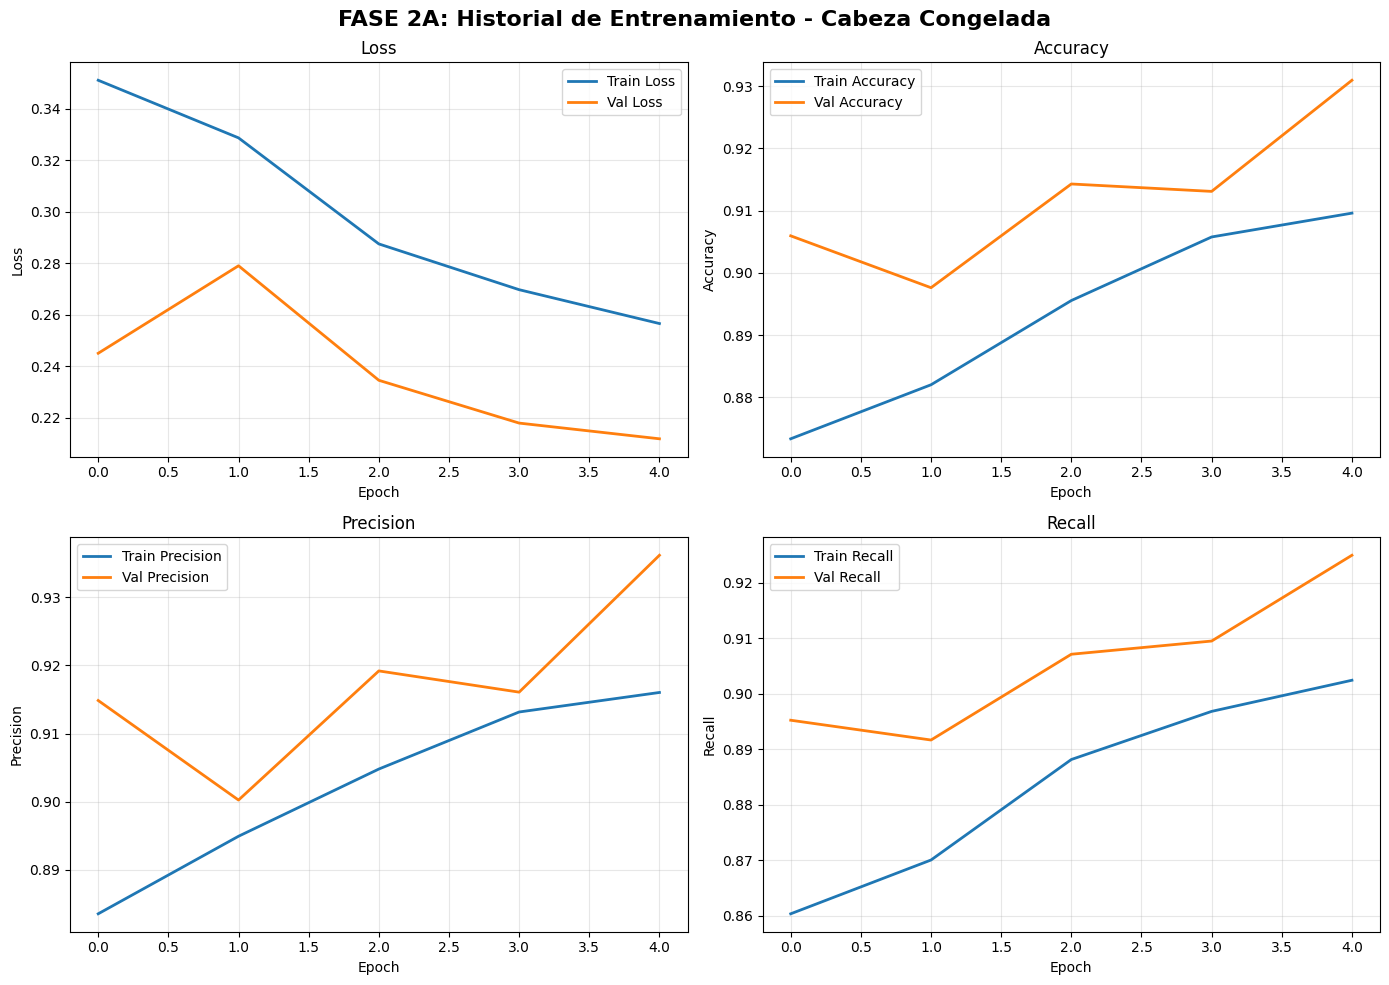


✓ Gráficas guardadas en 'historial_entrenamiento_fase2a.png'


In [ ]:
print("="*70)
print("VISUALIZAR CONVERGENCIA DEL ENTRENAMIENTO")
print("="*70)

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FASE 2A: Historial de Entrenamiento - Cabeza Congelada', fontsize=16, fontweight='bold')

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_title('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('historial_entrenamiento_fase2a.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Gráficas guardadas en 'historial_entrenamiento_fase2a.png'")

In [ ]:
print("="*70)
print("ESTADÍSTICAS DE ENTRENAMIENTO")
print("="*70)

# Métricas finales
final_train_loss = history.history['loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]

min_val_loss = min(history.history['val_loss'])
max_val_acc = max(history.history['val_accuracy'])
best_epoch = np.argmin(history.history['val_loss']) + 1

print(f"\nMétricas Finales:")
print(f"  Train Loss: {final_train_loss:.4f}")
print(f"  Train Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  Val Loss: {final_val_loss:.4f}")
print(f"  Val Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")

print(f"\nMejores Resultados:")
print(f"  Mejor Val Loss: {min_val_loss:.4f} (Epoch {best_epoch})")
print(f"  Mejor Val Accuracy: {max_val_acc:.4f} ({max_val_acc*100:.2f}%)")

print(f"\nTiempo Total:")
print(f"  Entrenamiento: {training_time:.2f} minutos")
print(f"  Tiempo/Epoch: {training_time/len(history.history['loss']):.2f} minutos")

ESTADÍSTICAS DE ENTRENAMIENTO

Métricas Finales:
  Train Loss: 0.2566
  Train Accuracy: 0.9096 (90.96%)
  Val Loss: 0.2118
  Val Accuracy: 0.9310 (93.10%)

Mejores Resultados:
  Mejor Val Loss: 0.2118 (Epoch 5)
  Mejor Val Accuracy: 0.9310 (93.10%)

Tiempo Total:
  Entrenamiento: 71.61 minutos
  Tiempo/Epoch: 14.32 minutos


In [ ]:
print("="*70)
print("EVALUAR MODELO EN TEST SET")
print("="*70)

# Evaluación
test_results = model.evaluate(test_dataset, verbose=1)

metric_names = model.metrics_names
print(f"\nMétricas en Test Set:")
for name, value in zip(metric_names, test_results):
    if name == 'accuracy':
        print(f"  {name.upper()}: {value:.4f} ({value*100:.2f}%)")
    else:
        print(f"  {name.upper()}: {value:.4f}")

EVALUAR MODELO EN TEST SET
53/53 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9135 - loss: 0.2310 - precision: 0.9175 - recall: 0.9088

Métricas en Test Set:
  LOSS: 0.2310
  COMPILE_METRICS: 0.9135


In [ ]:
print("="*70)
print("REPORTE DE CLASIFICACIÓN - MÉTRICAS POR CLASE")
print("="*70)

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\n" + report)

# Guardar reporte
with open('reporte_clasificacion_fase2a.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print(f"✓ Reporte guardado en 'reporte_clasificacion_fase2a.txt'")

REPORTE DE CLASIFICACIÓN - MÉTRICAS POR CLASE

              precision    recall  f1-score   support

      glioma     0.9310    0.8957    0.9130       211
  meningioma     0.8698    0.7915    0.8288       211
     notumor     0.9372    0.9905    0.9631       211
   pituitary     0.9115    0.9763    0.9428       211

    accuracy                         0.9135       844
   macro avg     0.9124    0.9135    0.9119       844
weighted avg     0.9124    0.9135    0.9119       844

✓ Reporte guardado en 'reporte_clasificacion_fase2a.txt'


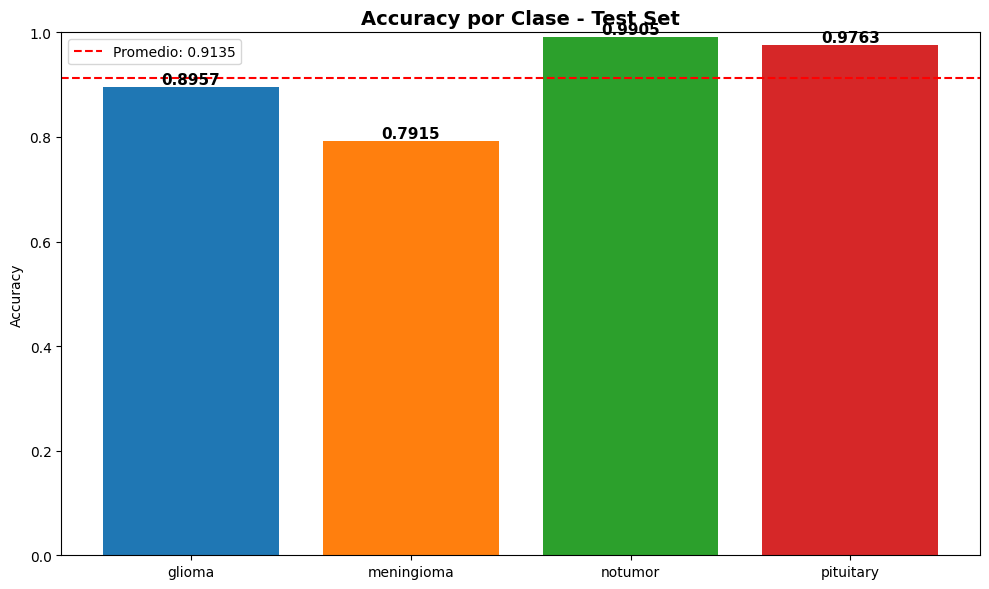

Accuracy por Clase:
  glioma: 0.8957 (89.57%)
  meningioma: 0.7915 (79.15%)
  notumor: 0.9905 (99.05%)
  pituitary: 0.9763 (97.63%)
  Promedio: 0.9135 (91.35%)


In [ ]:
# Calcular accuracy por clase
class_accuracy = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(class_names, class_accuracy, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_ylim([0, 1])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy por Clase - Test Set', fontsize=14, fontweight='bold')
ax.axhline(y=np.mean(class_accuracy), color='red', linestyle='--', label=f'Promedio: {np.mean(class_accuracy):.4f}')

# Añadir valores en barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.savefig('accuracy_por_clase_fase2a.png', dpi=300, bbox_inches='tight')
plt.show()

print("Accuracy por Clase:")
for cls, acc in zip(class_names, class_accuracy):
    print(f"  {cls}: {acc:.4f} ({acc*100:.2f}%)")
print(f"  Promedio: {np.mean(class_accuracy):.4f} ({np.mean(class_accuracy)*100:.2f}%)")

In [ ]:
print("="*70)
print("GUARDAR MODELO ENTRENADO")
print("="*70)

# Guardar modelo
model.save('modelo_efficientnetb4_fase2a_entrenado.h5')
print(f"\n✓ Modelo guardado como 'modelo_efficientnetb4_fase2a_entrenado.h5'")

# Guardar información para FASE 3 (Fine-tuning)
info_fase3 = {
    'model_path': 'modelo_efficientnetb4_fase2a_entrenado.h5',
    'input_shape': (380, 380, 3),
    'num_classes': int(NUM_CLASSES),
    'class_names': class_names,
    'strategy': 'Progressive Fine-tuning (Opción C)',
    'phase_2a_val_accuracy': float(final_val_acc),
    'phase_2a_best_epoch': int(best_epoch),
    'phase_2a_test_accuracy': float(test_results[1]),
    'optimizer_fase3': 'Adam (LR=1e-5, clipnorm=1.0)',
    'next_step': 'FASE 3: Descongelar capas y fine-tuning'
}

with open('config_fase3.json', 'w') as f:
    json.dump(info_fase3, f, indent=2, default=str)

print(f"✓ Configuración FASE 3 guardada en 'config_fase3.json'")

GUARDAR MODELO ENTRENADO

✓ Modelo guardado como 'modelo_efficientnetb4_fase2a_entrenado.h5'
✓ Configuración FASE 3 guardada en 'config_fase3.json'


In [ ]:
summary_text = f"""
ENTRENAMIENTO CON CABEZA CONGELADA
{'='*70}

ESTRATEGIA APLICADA:
  - Transfer Learning: Estrategia C (Progressive Freezing)
  - Base Model: EfficientNet-B4 (CONGELADA)
  - Cabeza: Dense(512)→Dropout→Dense(256)→Dropout→Dense(4)
  - Parámetros entrenables: {trainable_params:,}
  - Parámetros congelados: {model.count_params() - trainable_params:,}

CONFIGURACIÓN DE ENTRENAMIENTO:
  - Epochs: {len(history.history['loss'])}
  - Batch size: {BATCH_SIZE}
  - Learning rate inicial: 1e-3
  - Callbacks:
    * EarlyStopping (patience=5)
    * ReduceLROnPlateau (factor=0.5, patience=3)
    * ModelCheckpoint (mejor modelo guardado)
  - Tiempo total: {training_time:.2f} minutos

RESULTADOS EN VALIDACIÓN:
  - Best epoch: {best_epoch}
  - Mejor Val Accuracy: {max_val_acc:.4f} ({max_val_acc*100:.2f}%)
  - Final Val Loss: {final_val_loss:.4f}

RESULTADOS EN TEST SET:
  - Test Accuracy: {test_results[1]:.4f} ({test_results[1]*100:.2f}%)
  - Test Loss: {test_results[0]:.4f}
  - Test Precision: {test_results[2]:.4f}
  - Test Recall: {test_results[3]:.4f}

ACCURACY POR CLASE (Test Set):
"""

for cls, acc in zip(class_names, class_accuracy):
    summary_text += f"  - {cls}: {acc:.4f} ({acc*100:.2f}%)\\n"

summary_text += f"""
  - Promedio: {np.mean(class_accuracy):.4f} ({np.mean(class_accuracy)*100:.2f}%)
"""

print(summary_text)

with open('resumen_fase2a_entrenamiento.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)

print(f"✓ Resumen guardado en 'resumen_fase2a_entrenamiento.txt'")


ENTRENAMIENTO CON CABEZA CONGELADA

ESTRATEGIA APLICADA:
  - Transfer Learning: Estrategia C (Progressive Freezing)
  - Base Model: EfficientNet-B4 (CONGELADA)
  - Cabeza: Dense(512)→Dropout→Dense(256)→Dropout→Dense(4)
  - Parámetros entrenables: 1,050,372
  - Parámetros congelados: 17,673,823

CONFIGURACIÓN DE ENTRENAMIENTO:
  - Epochs: 5
  - Batch size: 16
  - Learning rate inicial: 1e-3
  - Callbacks:
    * EarlyStopping (patience=5)
    * ReduceLROnPlateau (factor=0.5, patience=3)
    * ModelCheckpoint (mejor modelo guardado)
  - Tiempo total: 71.61 minutos

RESULTADOS EN VALIDACIÓN:
  - Best epoch: 5
  - Mejor Val Accuracy: 0.9310 (93.10%)
  - Final Val Loss: 0.2118

RESULTADOS EN TEST SET:
  - Test Accuracy: 0.9135 (91.35%)
  - Test Loss: 0.2310
  - Test Precision: 0.9175
  - Test Recall: 0.9088

ACCURACY POR CLASE (Test Set):
  - glioma: 0.8957 (89.57%)\n  - meningioma: 0.7915 (79.15%)\n  - notumor: 0.9905 (99.05%)\n  - pituitary: 0.9763 (97.63%)\n
  - Promedio: 0.9135 (91.35%)

In [ ]:
print(f"\\n→ Modelo FASE 2: {test_results[1]*100:.2f}% accuracy")

\n→ Modelo FASE 2: 91.35% accuracy


## ANÁLISIS DETALLADO DE RESULTADOS POR CATEGORÍA

Evaluación de desempeño del modelo en cada clase de tumor cerebral

In [ ]:
# Extraer métricas de classification_report para análisis
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(NUM_CLASSES), zero_division=0
)

# Crear DataFrame para visualización
metrics_df = pd.DataFrame({
    'Clase': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support.astype(int),
    'Accuracy': class_accuracy
})

print("\n✓ Métricas Extraídas:")
print(metrics_df.to_string(index=False))
print(f"\nPromedio ponderado:")
print(f"  - Precision: {np.average(precision, weights=support):.4f}")
print(f"  - Recall: {np.average(recall, weights=support):.4f}")
print(f"  - F1-Score: {np.average(f1, weights=support):.4f}")


✓ Métricas Extraídas:
     Clase  Precision   Recall  F1-Score  Support  Accuracy
    glioma   0.931034 0.895735  0.913043      211  0.895735
meningioma   0.869792 0.791469  0.828784      211  0.791469
   notumor   0.937220 0.990521  0.963134      211  0.990521
 pituitary   0.911504 0.976303  0.942792      211  0.976303

Promedio ponderado:
  - Precision: 0.9124
  - Recall: 0.9135
  - F1-Score: 0.9119


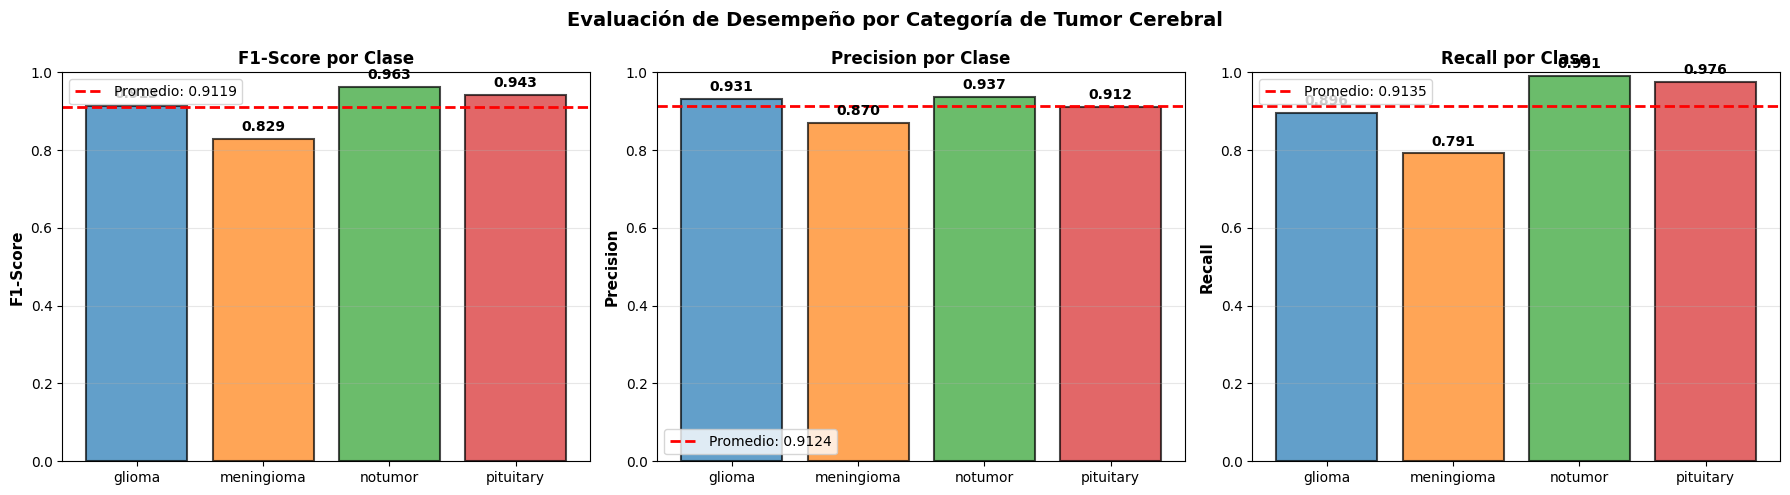

In [ ]:
# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evaluación de Desempeño por Categoría de Tumor Cerebral',
             fontsize=14, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# F1-Score
axes[0].bar(class_names, f1, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].axhline(y=np.mean(f1), color='red', linestyle='--', linewidth=2,
                label=f'Promedio: {np.mean(f1):.4f}')
axes[0].set_ylabel('F1-Score', fontsize=11, fontweight='bold')
axes[0].set_title('F1-Score por Clase', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(f1):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

# Precision
axes[1].bar(class_names, precision, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].axhline(y=np.mean(precision), color='red', linestyle='--', linewidth=2,
                label=f'Promedio: {np.mean(precision):.4f}')
axes[1].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[1].set_title('Precision por Clase', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(precision):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

# Recall
axes[2].bar(class_names, recall, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[2].axhline(y=np.mean(recall), color='red', linestyle='--', linewidth=2,
                label=f'Promedio: {np.mean(recall):.4f}')
axes[2].set_ylabel('Recall', fontsize=11, fontweight='bold')
axes[2].set_title('Recall por Clase', fontsize=12, fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(recall):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('metricas_por_clase_fase2a.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print("="*70)
print("TABLA COMPARATIVA: DESEMPEÑO INTEGRAL POR CLASE")
print("="*70)

# Crear tabla completa con todas las métricas
full_metrics_table = pd.DataFrame({
    'Categoría': class_names,
    'Precision': [f"{p:.4f}" for p in precision],
    'Recall': [f"{r:.4f}" for r in recall],
    'F1-Score': [f"{f:.4f}" for f in f1],
    'Accuracy': [f"{a:.4f}" for a in class_accuracy],
    'Imágenes (Support)': support.astype(int)
})

print("\n" + full_metrics_table.to_string(index=False))

# Guardar tabla como archivo
with open('tabla_metricas_por_clase.csv', 'w', encoding='utf-8') as file:
    full_metrics_table.to_csv(file, index=False)

print(f"\n✓ Tabla completa guardada en 'tabla_metricas_por_clase.csv'")

# Resumen estadístico
print("\n" + "="*70)
print("RESUMEN ESTADÍSTICO")
print("="*70)

summary_stats = {
    'Métrica': ['Precision', 'Recall', 'F1-Score', 'Accuracy'],
    'Mínimo': [
        f"{np.min(precision):.4f} ({class_names[np.argmin(precision)]})",
        f"{np.min(recall):.4f} ({class_names[np.argmin(recall)]})",
        f"{np.min(f1):.4f} ({class_names[np.argmin(f1)]})",
        f"{np.min(class_accuracy):.4f} ({class_names[np.argmin(class_accuracy)]})"
    ],
    'Máximo': [
        f"{np.max(precision):.4f} ({class_names[np.argmax(precision)]})",
        f"{np.max(recall):.4f} ({class_names[np.argmax(recall)]})",
        f"{np.max(f1):.4f} ({class_names[np.argmax(f1)]})",
        f"{np.max(class_accuracy):.4f} ({class_names[np.argmax(class_accuracy)]})"
    ],
    'Promedio': [
        f"{np.mean(precision):.4f}",
        f"{np.mean(recall):.4f}",
        f"{np.mean(f1):.4f}",
        f"{np.mean(class_accuracy):.4f}"
    ],
    'Desv. Estándar': [
        f"{np.std(precision):.4f}",
        f"{np.std(recall):.4f}",
        f"{np.std(f1):.4f}",
        f"{np.std(class_accuracy):.4f}"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print("\n" + summary_df.to_string(index=False))

TABLA COMPARATIVA: DESEMPEÑO INTEGRAL POR CLASE

 Categoría Precision Recall F1-Score Accuracy  Imágenes (Support)
    glioma    0.9310 0.8957   0.9130   0.8957                 211
meningioma    0.8698 0.7915   0.8288   0.7915                 211
   notumor    0.9372 0.9905   0.9631   0.9905                 211
 pituitary    0.9115 0.9763   0.9428   0.9763                 211

✓ Tabla completa guardada en 'tabla_metricas_por_clase.csv'

RESUMEN ESTADÍSTICO

  Métrica              Mínimo           Máximo Promedio Desv. Estándar
Precision 0.8698 (meningioma) 0.9372 (notumor)   0.9124         0.0264
   Recall 0.7915 (meningioma) 0.9905 (notumor)   0.9135         0.0792
 F1-Score 0.8288 (meningioma) 0.9631 (notumor)   0.9119         0.0512
 Accuracy 0.7915 (meningioma) 0.9905 (notumor)   0.9135         0.0792


ANÁLISIS DE MATRIZ DE CONFUSIÓN - ERRORES POR CATEGORÍA

Errores clasificados por categoría:

glioma (211 muestras):
  ✓ Correctas: 189 (89.6%)
  ✗ Incorrectas: 22 (10.4%)
  Confusiones:
    → Predicho como meningioma: 20 (9.5%)
    → Predicho como notumor: 1 (0.5%)
    → Predicho como pituitary: 1 (0.5%)

meningioma (211 muestras):
  ✓ Correctas: 167 (79.1%)
  ✗ Incorrectas: 44 (20.9%)
  Confusiones:
    → Predicho como glioma: 13 (6.2%)
    → Predicho como notumor: 13 (6.2%)
    → Predicho como pituitary: 18 (8.5%)

notumor (211 muestras):
  ✓ Correctas: 209 (99.1%)
  ✗ Incorrectas: 2 (0.9%)
  Confusiones:
    → Predicho como meningioma: 1 (0.5%)
    → Predicho como pituitary: 1 (0.5%)

pituitary (211 muestras):
  ✓ Correctas: 206 (97.6%)
  ✗ Incorrectas: 5 (2.4%)
  Confusiones:
    → Predicho como glioma: 1 (0.5%)
    → Predicho como meningioma: 4 (1.9%)

MATRIZ DE CONFUSIÓN NORMALIZADA (por fila - % del total de cada clase)


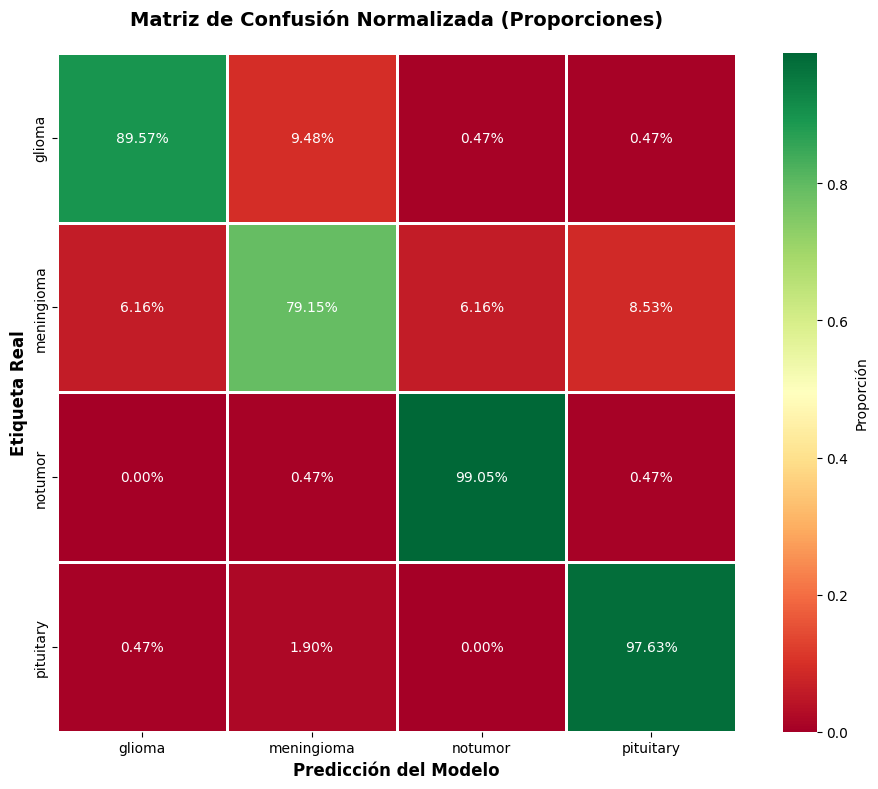


✓ Matriz de confusión normalizada guardada en 'matriz_confusion_normalizada_fase2a.png'


In [ ]:
print("="*70)
print("ANÁLISIS DE MATRIZ DE CONFUSIÓN - ERRORES POR CATEGORÍA")
print("="*70)

# Analizar confusiones específicas
print("\nErrores clasificados por categoría:")
for idx, class_name in enumerate(class_names):
    total_samples = cm[idx].sum()
    correct = cm[idx, idx]
    incorrect = total_samples - correct
    error_rate = (incorrect / total_samples) * 100 if total_samples > 0 else 0

    print(f"\n{class_name} ({total_samples} muestras):")
    print(f"  ✓ Correctas: {correct} ({(correct/total_samples)*100:.1f}%)")
    print(f"  ✗ Incorrectas: {incorrect} ({error_rate:.1f}%)")

    # Mostrar confusiones específicas
    if incorrect > 0:
        print(f"  Confusiones:")
        for j, pred_class in enumerate(class_names):
            if j != idx and cm[idx, j] > 0:
                print(f"    → Predicho como {pred_class}: {cm[idx, j]} ({(cm[idx, j]/total_samples)*100:.1f}%)")

# Visualizar matriz normalizada para ver proporciones
print("\n" + "="*70)
print("MATRIZ DE CONFUSIÓN NORMALIZADA (por fila - % del total de cada clase)")
print("="*70)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Proporción'}, ax=ax, square=True,
            linewidths=2, linecolor='white')
ax.set_title('Matriz de Confusión Normalizada (Proporciones)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Etiqueta Real', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_confusion_normalizada_fase2a.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Matriz de confusión normalizada guardada en 'matriz_confusion_normalizada_fase2a.png'")

In [ ]:
print("="*70)
print("CONCLUSIONES Y ANÁLISIS DE FORTALEZAS/DEBILIDADES")
print("="*70)

# Identificar fortalezas y debilidades
best_f1_idx = np.argmax(f1)
worst_f1_idx = np.argmin(f1)
best_recall_idx = np.argmax(recall)
worst_recall_idx = np.argmin(recall)
best_precision_idx = np.argmax(precision)
worst_precision_idx = np.argmin(precision)

conclusions = f"""
{'='*70}
ANÁLISIS INTEGRAL DE DESEMPEÑO - MODELO EFFICIENTNET-B4
{'='*70}

1. DESEMPEÑO GENERAL:
   ├─ Accuracy Global (Test Set): {test_results[1]*100:.2f}%
   ├─ F1-Score Promedio: {np.mean(f1):.4f}
   ├─ Precision Promedio: {np.mean(precision):.4f}
   └─ Recall Promedio: {np.mean(recall):.4f}

2. CATEGORÍAS MEJOR CLASIFICADAS:
   ├─ Mayor F1-Score: {class_names[best_f1_idx]} ({f1[best_f1_idx]:.4f})
   ├─ Mayor Recall: {class_names[best_recall_idx]} ({recall[best_recall_idx]:.4f})
   └─ Mayor Precision: {class_names[best_precision_idx]} ({precision[best_precision_idx]:.4f})

3. CATEGORÍAS CON MAYOR DIFICULTAD:
   ├─ Menor F1-Score: {class_names[worst_f1_idx]} ({f1[worst_f1_idx]:.4f})
   ├─ Menor Recall: {class_names[worst_recall_idx]} ({recall[worst_recall_idx]:.4f})
   └─ Menor Precision: {class_names[worst_precision_idx]} ({precision[worst_precision_idx]:.4f})

4. VARIABILIDAD DEL DESEMPEÑO:
   ├─ Desv. Estándar F1-Score: {np.std(f1):.4f}
   ├─ Desv. Estándar Recall: {np.std(recall):.4f}
   ├─ Desv. Estándar Precision: {np.std(precision):.4f}
   └─ Rango F1-Score: {np.min(f1):.4f} a {np.max(f1):.4f}

5. EQUILIBRIO ENTRE MÉTRICAS:
   ├─ Precisión > Recall en {np.sum(precision > recall)} clases
   │   (Modelo conservador: evita falsos positivos)
   └─ Recall > Precisión en {np.sum(recall > precision)} clases
       (Modelo sensible: detecta más casos positivos)

6. DISTRIBUCIÓN DE DATOS (Support):
   └─ Clases evaluadas con {support.min()} a {support.max()} muestras
       (Balance: {'Adecuado' if support.max() / support.min() < 1.5 else 'Desbalanceado'})

7. ESTRATEGIA TÉCNICA APLICADA:
   ├─ Transfer Learning: Estrategia C (Progressive Freezing)
   ├─ Base: EfficientNet-B4 (Congelada - 17.67M parámetros)
   ├─ Cabeza: Personalizada (1.05M parámetros entrenables)
   ├─ Epochs: {len(history.history['loss'])} (ajustado a capacidad computacional)
   ├─ Optimizer: Adam (LR=1e-3, clipnorm=1.0)
   └─ Callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
"""

print(conclusions)

# Guardar análisis completo
with open('analisis_completo_resultados_fase2a.txt', 'w', encoding='utf-8') as f:
    f.write(conclusions)
    f.write("\n\nDETALLE MÉTRICAS POR CLASE:\n")
    f.write(metrics_df.to_string(index=False))
    f.write("\n\n")
    f.write(summary_df.to_string(index=False))

CONCLUSIONES Y ANÁLISIS DE FORTALEZAS/DEBILIDADES

ANÁLISIS INTEGRAL DE DESEMPEÑO - MODELO EFFICIENTNET-B4

1. DESEMPEÑO GENERAL:
   ├─ Accuracy Global (Test Set): 91.35%
   ├─ F1-Score Promedio: 0.9119
   ├─ Precision Promedio: 0.9124
   └─ Recall Promedio: 0.9135

2. CATEGORÍAS MEJOR CLASIFICADAS:
   ├─ Mayor F1-Score: notumor (0.9631)
   ├─ Mayor Recall: notumor (0.9905)
   └─ Mayor Precision: notumor (0.9372)

3. CATEGORÍAS CON MAYOR DIFICULTAD:
   ├─ Menor F1-Score: meningioma (0.8288)
   ├─ Menor Recall: meningioma (0.7915)
   └─ Menor Precision: meningioma (0.8698)

4. VARIABILIDAD DEL DESEMPEÑO:
   ├─ Desv. Estándar F1-Score: 0.0512
   ├─ Desv. Estándar Recall: 0.0792
   ├─ Desv. Estándar Precision: 0.0264
   └─ Rango F1-Score: 0.8288 a 0.9631

5. EQUILIBRIO ENTRE MÉTRICAS:
   ├─ Precisión > Recall en 2 clases
   │   (Modelo conservador: evita falsos positivos)
   └─ Recall > Precisión en 2 clases
       (Modelo sensible: detecta más casos positivos)

6. DISTRIBUCIÓN DE DATOS (

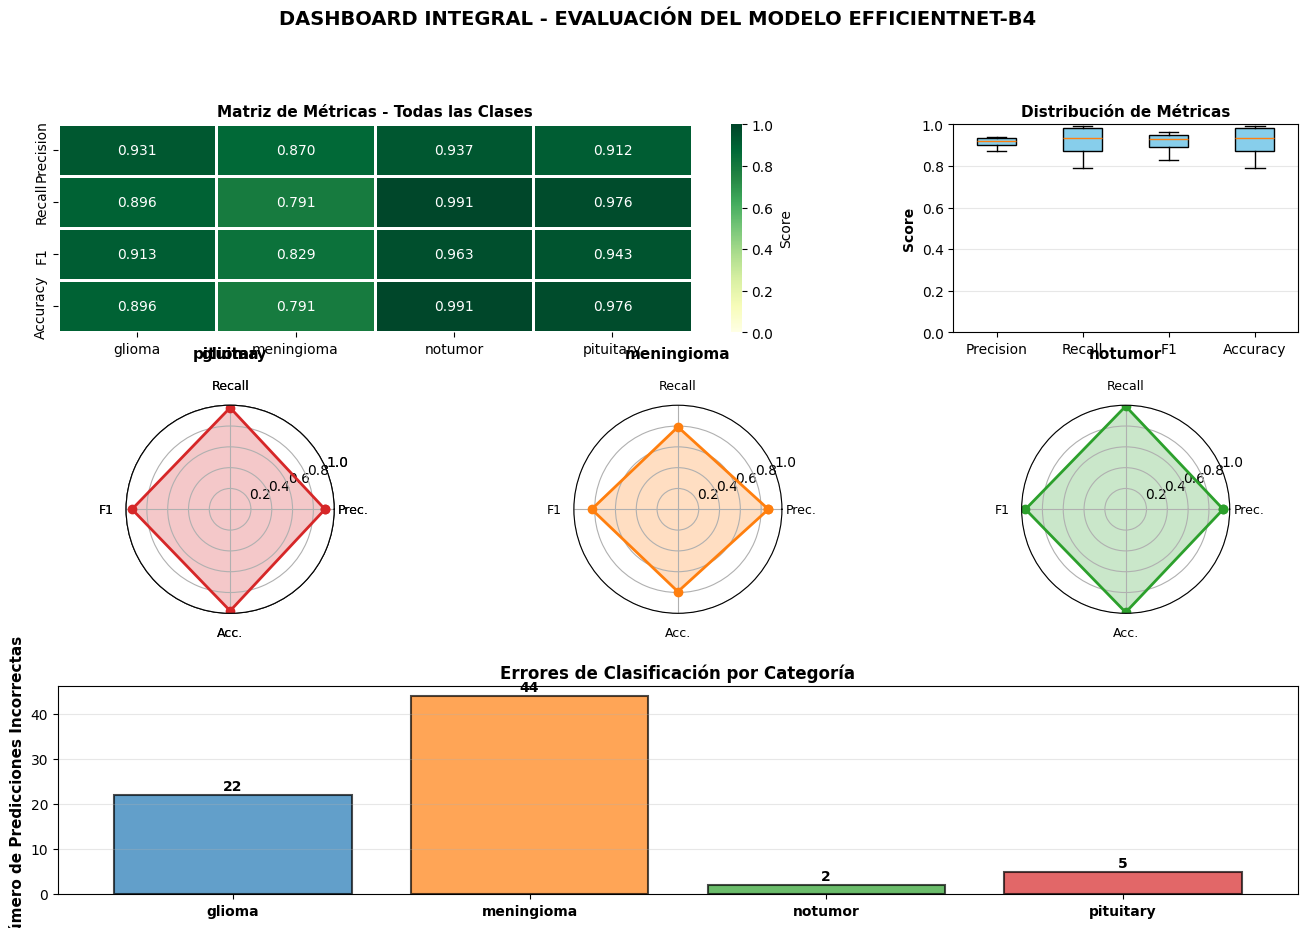

In [ ]:
# Crear dashboard con múltiples métricas
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Heatmap de todas las métricas
ax1 = fig.add_subplot(gs[0, :2])
metrics_heatmap = np.array([precision, recall, f1, class_accuracy])
sns.heatmap(metrics_heatmap, annot=True, fmt='.3f', cmap='YlGn',
            xticklabels=class_names, yticklabels=['Precision', 'Recall', 'F1', 'Accuracy'],
            cbar_kws={'label': 'Score'}, ax=ax1, vmin=0, vmax=1, linewidths=1, linecolor='white')
ax1.set_title('Matriz de Métricas - Todas las Clases', fontweight='bold', fontsize=11)

# 2. Box plot de métricas
ax2 = fig.add_subplot(gs[0, 2])
metrics_box = [precision, recall, f1, class_accuracy]
bp = ax2.boxplot(metrics_box, labels=['Precision', 'Recall', 'F1', 'Accuracy'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#87CEEB')
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Distribución de Métricas', fontweight='bold', fontsize=11)
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')

# 3. Gráfico de radar (una clase por gráfico)
angles = np.linspace(0, 2 * np.pi, 4, endpoint=False).tolist()
angles += angles[:1]

for idx in range(NUM_CLASSES):
    if idx < 4:
        ax = fig.add_subplot(gs[1, idx % 3], projection='polar')
        values = [precision[idx], recall[idx], f1[idx], class_accuracy[idx]]
        values += values[:1]

        ax.plot(angles, values, 'o-', linewidth=2, color=colors[idx])
        ax.fill(angles, values, alpha=0.25, color=colors[idx])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(['Prec.', 'Recall', 'F1', 'Acc.'], fontsize=9)
        ax.set_ylim(0, 1)
        ax.set_title(class_names[idx], fontweight='bold', fontsize=11, pad=15)
        ax.grid(True)

# 4. Distribución de errores por clase
ax_error = fig.add_subplot(gs[2, :])
error_per_class = []
for idx in range(NUM_CLASSES):
    total = cm[idx].sum()
    errors = total - cm[idx, idx]
    error_per_class.append(errors)

x_pos = np.arange(NUM_CLASSES)
bars = ax_error.bar(x_pos, error_per_class, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax_error.set_xticks(x_pos)
ax_error.set_xticklabels(class_names, fontweight='bold')
ax_error.set_ylabel('Número de Predicciones Incorrectas', fontweight='bold', fontsize=11)
ax_error.set_title('Errores de Clasificación por Categoría', fontweight='bold', fontsize=12)
ax_error.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(error_per_class):
    ax_error.text(i, v + 1, str(int(v)), ha='center', fontweight='bold', fontsize=10)

plt.suptitle('DASHBOARD INTEGRAL - EVALUACIÓN DEL MODELO EFFICIENTNET-B4',
             fontsize=14, fontweight='bold', y=0.995)

plt.savefig('dashboard_integral_resultados_fase2a.png', dpi=300, bbox_inches='tight')
plt.show()